Using ..\data\processed\sources_no_grounding_temp1.csv

Sets built: 30 rows


,prompt_id,category,run_id,n_urls,n_domains,urls,domains
0,P01,Faktische Frage,P01_R01,5,5,"[https://climate.nasa.gov/, https://public.wmo.int/en/our-mandate/climate/wmo-statement-state-of-global-climate, https://www.deutsches-klima-konsortium.de/de/klimawissen.html, https://www.ipcc.ch/...","[climate.nasa.gov, deutsches-klima-konsortium.de, ipcc.ch, klimafakten.de, public.wmo.int]"
1,P01,Faktische Frage,P01_R02,9,7,"[https://climate.nasa.gov/, https://report.ipcc.ch/ar6syr/pdf/IPCC_AR6_SYR_LongerReport.pdf, https://www.carbonbrief.org/, https://www.deutsches-klima-konsortium.de/, https://www.ipcc.ch/, https:/...","[carbonbrief.org, climate.nasa.gov, deutsches-klima-konsortium.de, ipcc.ch, report.ipcc.ch, science.org, worldweatherattribution.org]"
2,P01,Faktische Frage,P01_R03,5,5,"[https://climate.nasa.gov/, https://www.carbonbrief.org/, https://www.dwd.de/DE/leistungen/klimawandel/klimawandel.html, https://www.ipcc.ch/report/ar6/syr/, https://www.umweltbundesamt.de/themen/...","[carbonbrief.org, climate.nasa.gov, dwd.de, ipcc.ch, umweltbundesamt.de]"
3,P02,Faktische Frage,P02_R01,2,2,"[https://www.bmas.de/DE/Arbeit/Arbeitsrecht/Mindestlohn/mindestlohn.html, https://www.mindestlohn-kommission.de/DE/Bericht/bericht_node.html]","[bmas.de, mindestlohn-kommission.de]"
4,P02,Faktische Frage,P02_R02,2,2,"[https://www.bgbl.de/xaver/bgbl/start.xav?startbk=Bundesanzeiger_BGBl&jumpTo=bgbl123s1410.pdf, https://www.bmas.de/DE/Arbeit/Arbeitsrecht/Mindestlohn/mindestlohn.html]","[bgbl.de, bmas.de]"
5,P02,Faktische Frage,P02_R03,2,2,"[https://www.bmas.de/DE/Arbeit/Arbeitsrecht/Mindestlohn/mindestlohn.html, https://www.zoll.de/DE/Fachthemen/Arbeit/Mindestlohn-Mindestlohnverordnung/Mindestlohn-Mindestlohnverordnung/mindestlohn-m...","[bmas.de, zoll.de]"
6,P03,Faktische Frage,P03_R01,1,1,[https://www.statistik-berlin-brandenburg.de/einwohner-nach-zeitreihe],[statistik-berlin-brandenburg.de]
7,P03,Faktische Frage,P03_R02,1,1,[https://www.statistik-berlin-brandenburg.de/pressemitteilungen/2024/2024-09-26],[statistik-berlin-brandenburg.de]
8,P03,Faktische Frage,P03_R03,1,1,[https://www.statistik-berlin-brandenburg.de/einwohner-in-berlin-am-30-september-2023],[statistik-berlin-brandenburg.de]
9,P04,Faktische Frage,P04_R01,2,2,"[https://www.stw.berlin/beratung/studienfinanzierung/semesterticket.html, https://www.vbb.de/tickets/zeitkarten/semesterticket/]","[stw.berlin, vbb.de]"



Pairwise comparisons: 30


,prompt_id,category,n_runs,mean_url_jaccard,mean_domain_jaccard,url_pair_overlap_rate
1,P02,Faktische Frage,3,0.333333,0.333333,1.000000
6,P07,Prozedurale Frage,3,0.327778,0.666667,1.000000
7,P08,Aktuelles Thema,3,0.300000,0.666667,1.000000
8,P09,Aktuelles Thema,3,0.255952,0.633333,1.000000
0,P01,Faktische Frage,3,0.229798,0.305556,1.000000
4,P05,Prozedurale Frage,3,0.184524,0.416667,1.000000
3,P04,Faktische Frage,3,0.111111,1.000000,0.333333
5,P06,Prozedurale Frage,3,0.083333,0.777778,0.333333
2,P03,Faktische Frage,3,0.000000,1.000000,0.000000
9,P10,Aktuelles Thema,3,0.000000,0.445238,0.000000



Category aggregation:


...


Overall means:


,mean_url_jaccard,mean_domain_jaccard
0,0.182583,0.624524



Top domains:


,domain,occurrences,prompts
2,arbeitsagentur.de,64,1
60,service.berlin.de,50,1
42,ipcc.ch,37,1
62,statistik-berlin-brandenburg.de,31,1
66,tagesschau.de,29,1
11,bundesnetzagentur.de,24,2
77,verbraucherzentrale.de,24,1
23,climate.nasa.gov,23,1
34,gesetze-im-internet.de,21,2
82,zdf.de,21,1


C:\Users\lenaf\AppData\Local\Temp\ipykernel_19348\1661200532.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='mean_url_jaccard', y='prompt_id', palette='viridis')


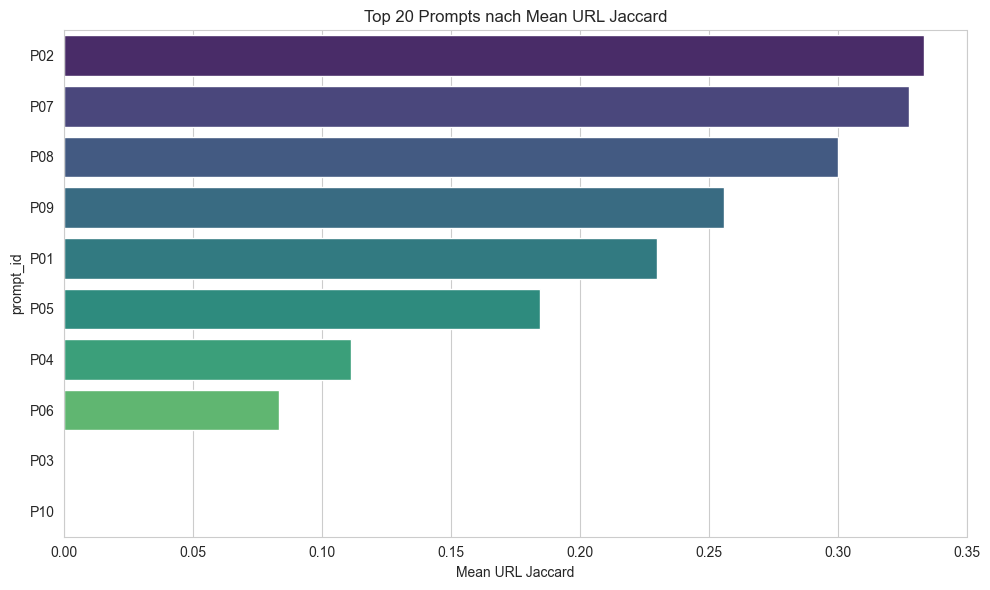

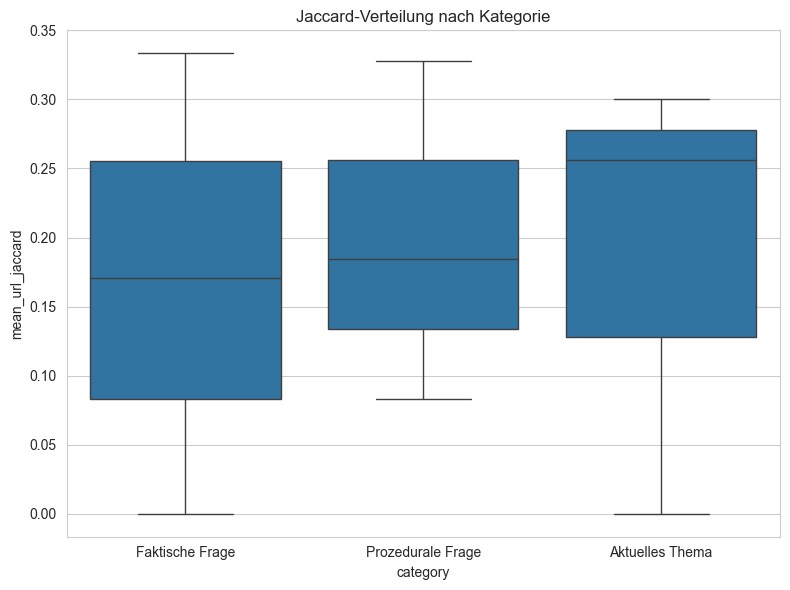

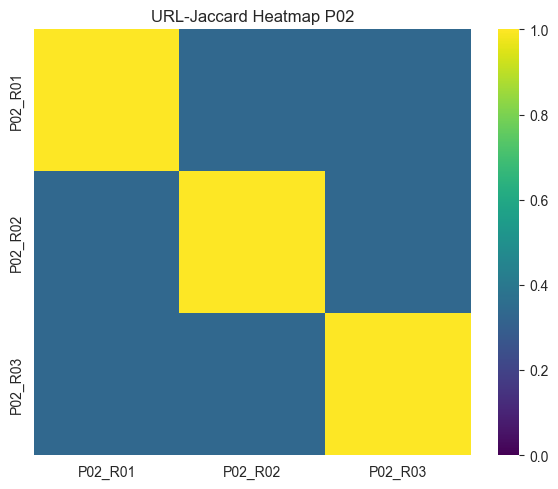

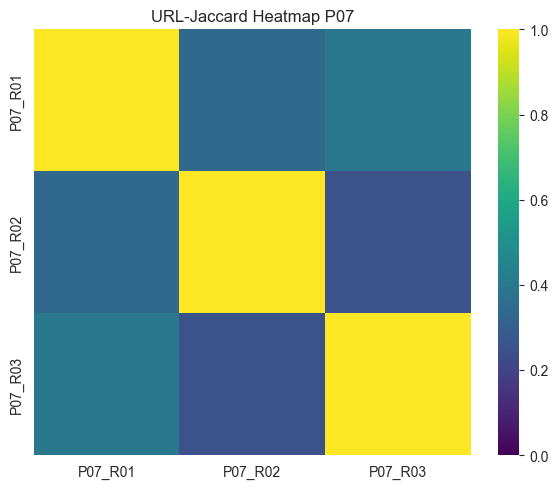

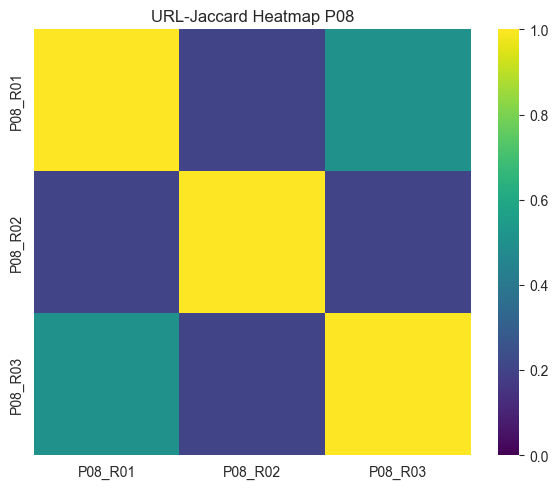


Analysezelle fertig. Führe diese Zelle im Notebook aus, um Tabellen und Grafiken inline zu sehen.


In [12]:
# Analysis cell: build sets, pairwise Jaccard, aggregations and plots
from IPython.display import display
from pathlib import Path
import json
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

# locate processed data folder relative to notebook
proc = Path('data/processed')
if not proc.exists():
    proc = Path('..') / 'data' / 'processed'

candidates = ['sources_no_grounding_temp1.csv','sources_no_grounding.csv','sources.csv']
SOURCES_FILE = None
for c in candidates:
    p = proc / c
    if p.exists():
        SOURCES_FILE = p
        break
if SOURCES_FILE is None:
    raise FileNotFoundError('No processed sources file found in data/processed')

RAW_FILE = Path('data/raw/raw_runs.jsonl')
if not RAW_FILE.exists():
    RAW_FILE = Path('..') / 'data' / 'raw' / 'raw_runs.jsonl'

print('Using', SOURCES_FILE)

sources = pd.read_csv(SOURCES_FILE)
# normalize
if 'timestamp' in sources.columns:
    sources['timestamp'] = pd.to_datetime(sources['timestamp'], errors='coerce')
sources['domain'] = sources['domain'].astype(str).str.lower().str.strip()
sources['url'] = sources['url'].astype(str).str.strip()

# load raw if available
raw = pd.DataFrame()
if RAW_FILE.exists():
    recs = []
    with RAW_FILE.open('r', encoding='utf-8') as f:
        for line in f:
            line=line.strip()
            if line:
                recs.append(json.loads(line))
    raw = pd.DataFrame(recs)

# base of runs (prompt_id, category, run_id)
run_base = (raw[['prompt_id','category','run_id']].drop_duplicates() if not raw.empty else sources[['prompt_id','category','run_id']].drop_duplicates())

# Build sets per prompt x run
sets = []
for (pid, cat), grp in run_base.groupby(['prompt_id','category']):
    for rid in sorted(grp['run_id'].unique()):
        sub = sources[(sources['prompt_id']==pid)&(sources['run_id']==rid)]
        urls = sorted(sub['url'].dropna().unique())
        domains = sorted(sub['domain'].dropna().unique())
        sets.append({'prompt_id': pid, 'category': cat, 'run_id': rid, 'n_urls': len(urls), 'n_domains': len(domains), 'urls': urls, 'domains': domains})
sets_df = pd.DataFrame(sets)

print('\nSets built:', len(sets_df), 'rows')
display(sets_df.head(10))

# Pairwise Jaccard per prompt

def jaccard(a,b):
    a=set(a); b=set(b)
    if not a and not b: return 1.0
    if not a or not b: return 0.0
    return len(a & b) / len(a | b)

pair_rows = []
agg_rows = []
for (pid, cat), grp in run_base.groupby(['prompt_id','category']):
    run_ids = sorted(grp['run_id'].unique())
    if len(run_ids) < 2:
        agg_rows.append({'prompt_id': pid, 'category': cat, 'n_runs': len(run_ids), 'mean_url_jaccard': np.nan, 'mean_domain_jaccard': np.nan, 'url_pair_overlap_rate': np.nan})
        continue
    url_js = []
    dom_js = []
    overlap_any = []
    for r1, r2 in combinations(run_ids, 2):
        set1 = sets_df[(sets_df['prompt_id']==pid)&(sets_df['run_id']==r1)]['urls'].iloc[0]
        set2 = sets_df[(sets_df['prompt_id']==pid)&(sets_df['run_id']==r2)]['urls'].iloc[0]
        uj = jaccard(set1, set2)
        set1d = sets_df[(sets_df['prompt_id']==pid)&(sets_df['run_id']==r1)]['domains'].iloc[0]
        set2d = sets_df[(sets_df['prompt_id']==pid)&(sets_df['run_id']==r2)]['domains'].iloc[0]
        dj = jaccard(set1d, set2d)
        url_js.append(uj); dom_js.append(dj)
        overlap_any.append(int(len(set(set1)&set(set2))>0))
        pair_rows.append({'prompt_id': pid, 'category': cat, 'run1': r1, 'run2': r2, 'url_jaccard': uj, 'domain_jaccard': dj, 'overlap_any': int(len(set(set1)&set(set2))>0)})
    agg_rows.append({'prompt_id': pid, 'category': cat, 'n_runs': len(run_ids), 'mean_url_jaccard': np.mean(url_js), 'mean_domain_jaccard': np.mean(dom_js), 'url_pair_overlap_rate': np.mean(overlap_any)})

pairs_df = pd.DataFrame(pair_rows)
jaccard_df = pd.DataFrame(agg_rows).sort_values('mean_url_jaccard', ascending=False)

print('\nPairwise comparisons:', len(pairs_df))
display(jaccard_df.head(20))

# Aggregation per category and overall
category_agg = jaccard_df.groupby('category').agg(mean_url_jaccard=('mean_url_jaccard','mean'), mean_domain_jaccard=('mean_domain_jaccard','mean'), n_prompts=('prompt_id','nunique')).reset_index()
overall = {'mean_url_jaccard': jaccard_df['mean_url_jaccard'].mean(), 'mean_domain_jaccard': jaccard_df['mean_domain_jaccard'].mean()}

print('\nCategory aggregation:')
display(category_agg)
print('\nOverall means:')
display(pd.DataFrame([overall]))

# Domain frequencies overall
domain_freq = sources.groupby('domain').agg(occurrences=('domain','size'), prompts=('prompt_id','nunique')).reset_index().sort_values('occurrences', ascending=False)
print('\nTop domains:')
display(domain_freq.head(20))

# Plots: Top prompts by mean_url_jaccard and boxplot by category
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plot_df = jaccard_df.dropna(subset=['mean_url_jaccard']).sort_values('mean_url_jaccard', ascending=False).head(20)
sns.barplot(data=plot_df, x='mean_url_jaccard', y='prompt_id', palette='viridis')
plt.title('Top 20 Prompts nach Mean URL Jaccard')
plt.xlabel('Mean URL Jaccard')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=jaccard_df.dropna(subset=['mean_url_jaccard']), x='category', y='mean_url_jaccard')
plt.title('Jaccard-Verteilung nach Kategorie')
plt.tight_layout()
plt.show()

# Heatmaps for up to 3 prompts with most runs
heat_prompts = jaccard_df.sort_values('n_runs', ascending=False).head(3)['prompt_id'].tolist()
for p in heat_prompts:
    runs = run_base[run_base['prompt_id']==p]['run_id'].unique()
    if len(runs)<2: continue
    m = np.zeros((len(runs), len(runs)))
    for i,r1 in enumerate(runs):
        for j,r2 in enumerate(runs):
            set1 = sets_df[(sets_df['prompt_id']==p)&(sets_df['run_id']==r1)]['urls'].iloc[0]
            set2 = sets_df[(sets_df['prompt_id']==p)&(sets_df['run_id']==r2)]['urls'].iloc[0]
            m[i,j] = jaccard(set1,set2)
    plt.figure(figsize=(6,5))
    sns.heatmap(m, xticklabels=runs, yticklabels=runs, vmin=0, vmax=1, cmap='viridis')
    plt.title(f'URL-Jaccard Heatmap {p}')
    plt.tight_layout()
    plt.show()

print('\nAnalysezelle fertig. Führe diese Zelle im Notebook aus, um Tabellen und Grafiken inline zu sehen.')

# Analyse-Pipeline: Übersicht

Dieser Abschnitt implementiert die vorgeschlagene Pipeline:
1. Daten laden (`sources.csv`, optional `raw_runs.jsonl`)
2. Datenqualität prüfen
3. Set-Bildung (URLs / Domains pro `prompt_id` x `run_id`)
4. Paarweise Jaccard-Berechnung pro Prompt
5. Aggregation und Visualisierung



In [13]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

# Pfade
SOURCES_FILE = Path("../data/processed/sources_no_grounding_temp1.csv")
RAW_FILE = Path("../data/raw/raw_runs_no_grounding_temp1.jsonl")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print('Sources exists:', SOURCES_FILE.exists(), SOURCES_FILE)
print('Raw exists:', RAW_FILE.exists(), RAW_FILE)


Sources exists: True ..\data\processed\sources_no_grounding_temp1.csv
Raw exists: True ..\data\raw\raw_runs_no_grounding_temp1.jsonl


In [14]:
# 1) Daten laden
sources = pd.read_csv(SOURCES_FILE)
# optional: raw
raw_records = []
if RAW_FILE.exists():
    with RAW_FILE.open('r', encoding='utf-8') as f:
        for line in f:
            line=line.strip()
            if line:
                raw_records.append(json.loads(line))
raw = pd.DataFrame(raw_records)

# Normalisierung
if 'timestamp' in sources.columns:
    sources['timestamp'] = pd.to_datetime(sources['timestamp'], errors='coerce')
sources['domain'] = sources['domain'].astype(str).str.lower().str.strip()
sources['url'] = sources['url'].astype(str).str.strip()

# Basis-Checks
print('Zeilen sources:', len(sources))
print('Eindeutige Prompts:', sources['prompt_id'].nunique())
print('Runs mit Quellen:', sources['run_id'].nunique())
if not raw.empty:
    print('Total runs (raw):', raw['run_id'].nunique())

# run_base (Runs pro Prompt)
run_base = (raw[['prompt_id','category','run_id']].drop_duplicates() if not raw.empty else sources[['prompt_id','category','run_id']].drop_duplicates())



Zeilen sources: 726
Eindeutige Prompts: 10
Runs mit Quellen: 200
Total runs (raw): 200


In [15]:
# 2) Set-Bildung und Paarweise Jaccard

def jaccard(a,b):
    a=set(a); b=set(b)
    if not a and not b: return 1.0
    if not a or not b: return 0.0
    return len(a & b) / len(a | b)

jaccard_rows=[]

for (prompt_id, category), grp in run_base.groupby(['prompt_id','category']):
    run_ids = sorted(grp['run_id'].unique())
    # build sets
    url_sets={}
    domain_sets={}
    for rid in run_ids:
        sub = sources[(sources['prompt_id']==prompt_id) & (sources['run_id']==rid)]
        url_sets[rid] = set(sub['url'])
        domain_sets[rid] = set(sub['domain'])
    # pairwise
    url_j=[]; dom_j=[]; overlap_any=[]
    for r1,r2 in combinations(run_ids,2):
        uj = jaccard(url_sets[r1], url_sets[r2])
        dj = jaccard(domain_sets[r1], domain_sets[r2])
        url_j.append(uj); dom_j.append(dj)
        overlap_any.append(int(len(url_sets[r1]&url_sets[r2])>0))
    jaccard_rows.append({
        'prompt_id': prompt_id,
        'category': category,
        'n_runs': len(run_ids),
        'mean_url_jaccard': np.mean(url_j) if url_j else np.nan,
        'mean_domain_jaccard': np.mean(dom_j) if dom_j else np.nan,
        'url_pair_overlap_rate': np.mean(overlap_any) if overlap_any else np.nan
    })

jaccard_df = pd.DataFrame(jaccard_rows).sort_values('mean_url_jaccard', ascending=False)

jaccard_df.head()


,prompt_id,category,n_runs,mean_url_jaccard,mean_domain_jaccard,url_pair_overlap_rate
6,P07,Prozedurale Frage,20,0.433434,0.950000,1.000000
1,P02,Faktische Frage,20,0.301316,0.442018,1.000000
7,P08,Aktuelles Thema,20,0.260702,0.559123,0.721053
8,P09,Aktuelles Thema,20,0.193993,0.509129,0.926316
0,P01,Faktische Frage,20,0.186607,0.357611,0.947368


In [16]:
# 3) Aggregation: pro Prompt, Kategorie, Insgesamt
prompt_agg = jaccard_df.copy()
category_agg = jaccard_df.groupby('category').agg(mean_url_jaccard=('mean_url_jaccard','mean'), mean_domain_jaccard=('mean_domain_jaccard','mean'), count_prompts=('prompt_id','nunique')).reset_index()
overall = pd.Series({'mean_url_jaccard': jaccard_df['mean_url_jaccard'].mean(), 'mean_domain_jaccard': jaccard_df['mean_domain_jaccard'].mean()})

print('Prompt aggregation sample:')
display(prompt_agg.head())
print('\nCategory aggregation:')
display(category_agg)
print('\nOverall:')
print(overall)


Prompt aggregation sample:


,prompt_id,category,n_runs,mean_url_jaccard,mean_domain_jaccard,url_pair_overlap_rate
6,P07,Prozedurale Frage,20,0.433434,0.950000,1.000000
1,P02,Faktische Frage,20,0.301316,0.442018,1.000000
7,P08,Aktuelles Thema,20,0.260702,0.559123,0.721053
8,P09,Aktuelles Thema,20,0.193993,0.509129,0.926316
0,P01,Faktische Frage,20,0.186607,0.357611,0.947368



Category aggregation:


,category,mean_url_jaccard,mean_domain_jaccard,count_prompts
0,Aktuelles Thema,0.155789,0.546424,3
1,Faktische Frage,0.148889,0.570828,4
2,Prozedurale Frage,0.205219,0.777836,3



Overall:
mean_url_jaccard       0.167858
mean_domain_jaccard    0.625609
dtype: float64


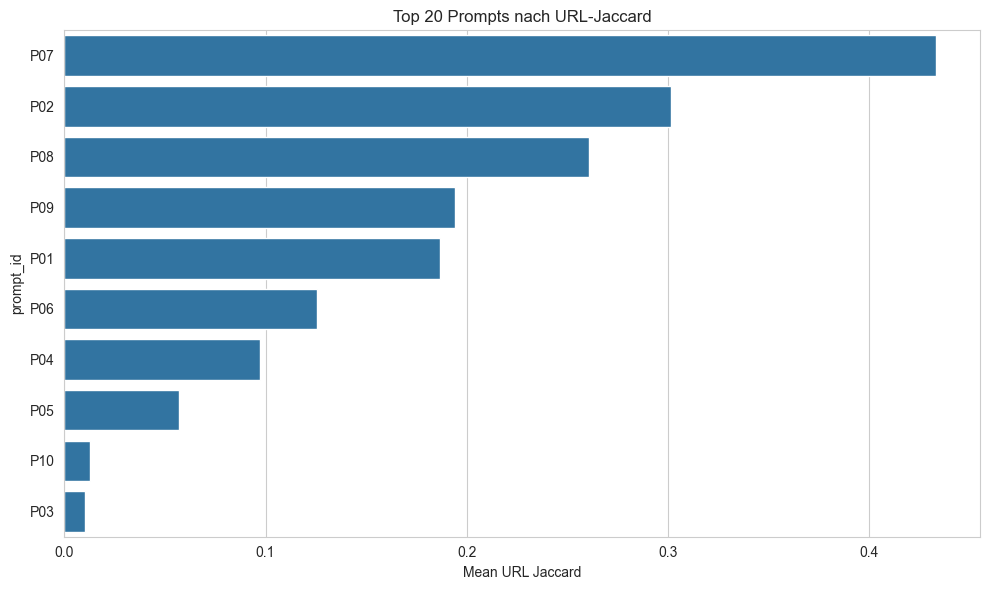

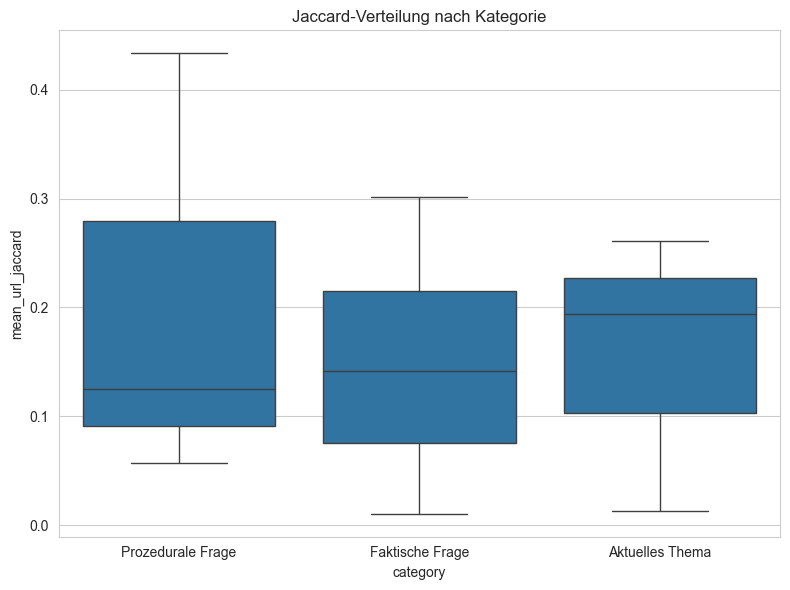

In [17]:
# 4) Grafiken: Balken, Boxplot, Heatmap-Vorlage
plt.figure(figsize=(10,6))
sns.barplot(data=prompt_agg.sort_values('mean_url_jaccard', ascending=False).head(20), x='mean_url_jaccard', y='prompt_id')
plt.title('Top 20 Prompts nach URL-Jaccard')
plt.xlabel('Mean URL Jaccard')
plt.tight_layout()

plt.figure(figsize=(8,6))
sns.boxplot(data=jaccard_df, x='category', y='mean_url_jaccard')
plt.title('Jaccard-Verteilung nach Kategorie')
plt.tight_layout()

# Heatmap template für ausgewählten Prompt (wähle prompt_id manuall)
SELECT_PROMPT = None  # z.B. 'P01'
if SELECT_PROMPT is not None:
    runs = run_base[run_base['prompt_id']==SELECT_PROMPT]['run_id'].unique()
    m = np.zeros((len(runs), len(runs)))
    for i,r1 in enumerate(runs):
        for j,r2 in enumerate(runs):
            set1 = set(sources[(sources['prompt_id']==SELECT_PROMPT)&(sources['run_id']==r1)]['url'])
            set2 = set(sources[(sources['prompt_id']==SELECT_PROMPT)&(sources['run_id']==r2)]['url'])
            m[i,j] = jaccard(set1,set2)
    plt.figure(figsize=(8,6))
    sns.heatmap(m, xticklabels=runs, yticklabels=runs, vmin=0, vmax=1, cmap='viridis')
    plt.title(f'URL-Jaccard Heatmap {SELECT_PROMPT}')
    plt.show()
